# Analyse : la cible, les features, et ce qu'on sait déjà

Ce notebook rassemble tout ce que les données ont dit jusqu'ici, avec les
diagrammes qui rendent chaque conclusion lisible.

**Discipline de fuite, appliquée cellule par cellule.** Deux régimes cohabitent
ici et il faut savoir lequel s'applique :

- Les mesures qui portent sur **le marché** (ses baselines, sa calibration) sont
  calculées sur la saison de test 2025-26. C'est légitime : le marché n'est pas
  notre modèle, c'est la référence à laquelle on se compare.
- Les mesures qui portent sur **nos features** (corrélations, pouvoir prédictif)
  sont calculées sur les **saisons d'entraînement uniquement**, 2020-21 à
  2023-24. Choisir ses features en ayant vu le test, c'est du surapprentissage
  manuel qu'aucun test automatique ne peut détecter.

Chaque section dit lequel des deux régimes elle utilise.

In [1]:
# The kernel starts in notebooks/, so the repo root has to be importable.
import sys
from pathlib import Path

ROOT = Path.cwd() if (Path.cwd() / "data").exists() else Path.cwd().parent
if str(ROOT) not in sys.path:
    sys.path.insert(0, str(ROOT))
print("racine du projet :", ROOT)

racine du projet : /Users/mamadoudiallo/Documents/Personel/foot-prediction


In [2]:
import matplotlib.pyplot as plt
import numpy as np
import polars as pl
from matplotlib.colors import LinearSegmentedColormap

from src.eval.baselines import (
    coherent_odds_mask,
    home_baseline,
    market_baseline,
    uniform_baseline,
)
from src.eval.metrics import (
    accuracy,
    brier_score_multiclass,
    calibration_bins,
    expected_calibration_error,
    log_loss,
)
from src.eval.splits import TEST_SEASON, TRAIN_SEASONS, chronological_split
from src.features.build import FEATURE_COLUMNS, build_features
from src.features.elo import EloRatings

# Validated categorical palette, fixed slot order. Never cycled.
BLUE, ORANGE, AQUA, YELLOW, MAGENTA = (
    "#2a78d6",
    "#eb6834",
    "#1baf7a",
    "#eda100",
    "#e87ba4",
)
SERIES = (BLUE, ORANGE, AQUA, YELLOW, MAGENTA)
SURFACE, INK, INK_2, RULE = "#fcfcfb", "#0b0b0b", "#52514e", "#d8d7d2"
# Diverging: two hues plus the documented neutral grey midpoint. Never a rainbow.
CMAP_DIVERGING = LinearSegmentedColormap.from_list(
    "blue_red",
    [
        "#0d366b",
        "#256abf",
        "#6da7ec",
        "#cde2fb",
        "#f0efec",
        "#f7c3c2",
        "#ee8584",
        "#e34948",
        "#8f2a29",
    ],
)

plt.rcParams.update(
    {
        "figure.facecolor": SURFACE,
        "axes.facecolor": SURFACE,
        "savefig.facecolor": SURFACE,
        "figure.dpi": 120,
        "font.size": 10,
        "text.color": INK,
        "axes.labelcolor": INK_2,
        "axes.titlecolor": INK,
        "xtick.color": INK_2,
        "ytick.color": INK_2,
        "axes.edgecolor": RULE,
        "axes.linewidth": 0.8,
        "axes.spines.top": False,
        "axes.spines.right": False,
        "xtick.major.size": 0,
        "ytick.major.size": 0,
        "grid.color": "#e8e7e3",
        "grid.linewidth": 0.6,
        "legend.frameon": False,
        "lines.linewidth": 2,
    }
)
pl.Config.set_tbl_hide_dataframe_shape(True)
pl.Config.set_tbl_width_chars(190)
pl.Config.set_tbl_rows(30)

FIGDIR = ROOT / "reports" / "figures"
FIGDIR.mkdir(parents=True, exist_ok=True)


def savefig(name: str) -> None:
    # Persist the figure under reports/ so the visuals outlive the notebook.
    plt.tight_layout()
    plt.savefig(FIGDIR / f"{name}.png", dpi=150, bbox_inches="tight")
    plt.show()


MATCHES = pl.read_parquet(ROOT / "data" / "processed" / "matches.parquet").sort("date")
TRAIN, VALID, TEST = chronological_split(MATCHES)
print(
    f"{MATCHES.height} matchs  |  train {TRAIN.height}  valid {VALID.height}  test {TEST.height}"
)
print(f"train : {', '.join(TRAIN_SEASONS)}   test : {TEST_SEASON}")

10734 matchs  |  train 7230  valid 1752  test 1752
train : 2020-21, 2021-22, 2022-23, 2023-24   test : 2025-26


## 1. Le terrain de jeu

*Régime : saison de test. Ce sont les baselines, pas notre modèle.*

Avant de construire quoi que ce soit, il faut savoir entre quelles bornes le
résultat aura un sens. Sans ce cadre, un log-loss de 1.03 ne se distingue pas
d'un log-loss de 0.97 — alors que l'un est médiocre et l'autre excellent.

In [3]:
test = TEST.filter(coherent_odds_mask(TEST, "avg"))
outcomes = test["result"].to_list()
BASELINES = {
    "uniform": uniform_baseline(TRAIN, n_rows=test.height),
    "home": home_baseline(n_rows=test.height),
    "market": market_baseline(test, book="avg", method="power"),
}
scores = pl.DataFrame(
    [
        {
            "baseline": name,
            "log_loss": round(log_loss(p, outcomes), 4),
            "brier": round(brier_score_multiclass(p, outcomes), 4),
            "ece": round(expected_calibration_error(p, outcomes), 4),
            "accuracy_info": round(accuracy(p, outcomes), 4),
        }
        for name, p in BASELINES.items()
    ]
)
MARKET = BASELINES["market"]
FLOOR = float(-(MARKET * np.log(MARKET)).sum(axis=1).mean())
NO_KNOWLEDGE = float(np.log(3))
print(f"plancher d'entropie du marche : {FLOOR:.4f}")
print(f"ne rien savoir (ln 3)         : {NO_KNOWLEDGE:.4f}")
scores

plancher d'entropie du marche : 0.9808
ne rien savoir (ln 3)         : 1.0986


baseline,log_loss,brier,ece,accuracy_info
str,f64,f64,f64,f64
"""uniform""",1.0721,0.6485,0.0078,0.4403
"""home""",19.3307,1.1194,0.3731,0.4403
"""market""",0.9769,0.5818,0.0086,0.5346


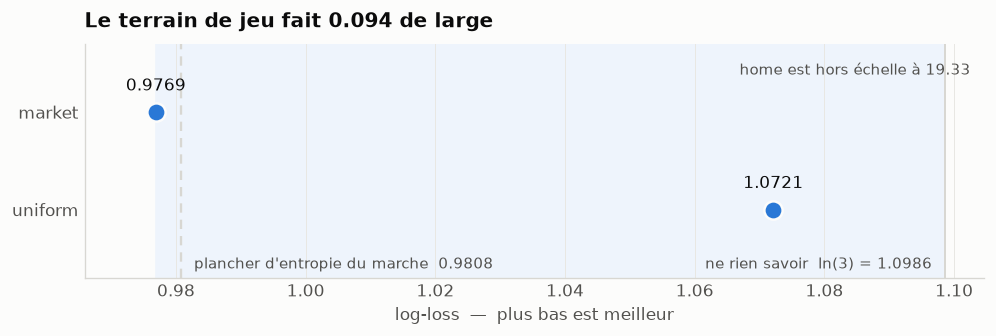

In [4]:
fig, ax = plt.subplots(figsize=(8.4, 2.9))
names = ["uniform", "market"]
values = [scores.filter(pl.col("baseline") == n)["log_loss"][0] for n in names]

best = min(values)
ax.axvspan(best, NO_KNOWLEDGE, color="#eef4fc", zorder=0)
ax.axvline(NO_KNOWLEDGE, color=RULE, linewidth=1.2, zorder=1)
ax.axvline(FLOOR, color=RULE, linewidth=1.4, linestyle=(0, (4, 3)), zorder=2)
ax.scatter(values, names, s=120, color=BLUE, edgecolor=SURFACE, linewidth=1.5, zorder=3)
for name, value in zip(names, values, strict=True):
    ax.annotate(
        f"{value:.4f}",
        (value, name),
        xytext=(0, 13),
        textcoords="offset points",
        ha="center",
        fontsize=10,
        color=INK,
    )

# Reference labels along the bottom edge: x in data units, y in axes fraction.
bottom = ax.get_xaxis_transform()
ax.text(
    NO_KNOWLEDGE - 0.002,
    0.04,
    f"ne rien savoir  ln(3) = {NO_KNOWLEDGE:.4f}",
    transform=bottom,
    ha="right",
    fontsize=9,
    color=INK_2,
)
ax.text(
    FLOOR + 0.002,
    0.04,
    f"plancher d'entropie du marche  {FLOOR:.4f}",
    transform=bottom,
    ha="left",
    fontsize=9,
    color=INK_2,
)
ax.set_xlim(best - 0.011, NO_KNOWLEDGE + 0.006)
ax.set_ylim(-0.7, 1.7)
ax.set_xlabel("log-loss  —  plus bas est meilleur")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title(
    "Le terrain de jeu fait 0.094 de large", loc="left", fontweight="bold", pad=10
)
ax.text(
    0.985,
    0.92,
    "home est hors échelle à 19.33",
    transform=ax.transAxes,
    ha="right",
    va="top",
    fontsize=9,
    color=INK_2,
)
savefig("06_terrain_de_jeu")

La zone bleutée est tout l'espace utile, de `market` à `ln(3)`. À droite,
`ln(3) = 1.0986` : ne rien savoir du tout.

La ligne en tirets est le **plancher d'entropie** : l'incertitude irréductible
du football, estimée par l'entropie moyenne des probabilités que le marché
lui-même annonce. Un modèle qui descend nettement sous cette ligne n'a pas eu
une bonne idée, il a vu le résultat.

Et le marché est **0.004 sous son propre plancher**. Ce n'est pas une
contradiction : le plancher est ce que le marché *attendrait* de payer si ses
probabilités étaient exactes, et 2025-26 s'est trouvée un peu plus prévisible
que ce qu'il avait annoncé. Sur 1 751 matchs, un écart de cette taille est une
fluctuation favorable, pas une compétence — et c'est un bon rappel que ces
chiffres ont eux aussi une barre d'erreur.

`home` est à 19.33, tellement loin qu'il ne rentre pas sur le graphe. C'est
l'objet de la section suivante.

## 2. Le piège de l'accuracy

*Régime : saison de test.*

`home` et `uniform` désignent le même vainqueur à chaque match, donc ont
exactement la même accuracy. Leur log-loss diffère d'un facteur 18.

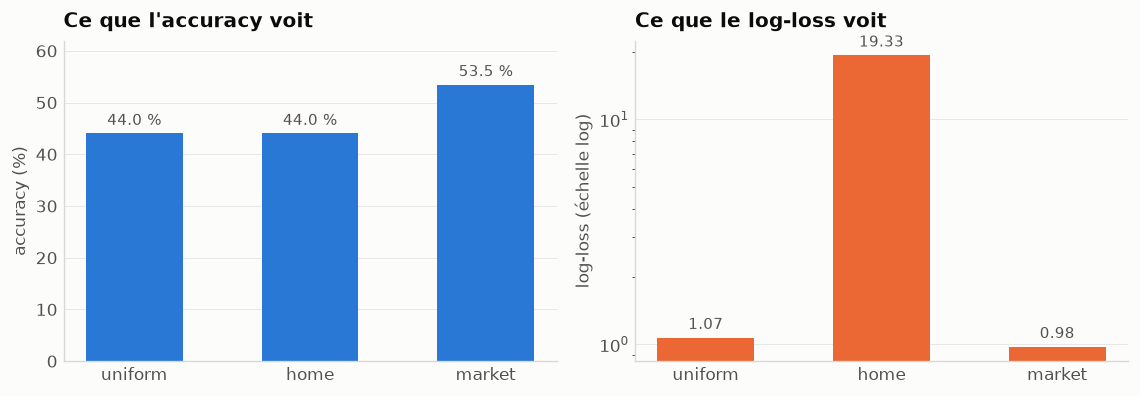

In [5]:
fig, axes = plt.subplots(1, 2, figsize=(9.6, 3.4))
labels = scores["baseline"].to_list()
x = np.arange(len(labels))

acc = 100 * np.array(scores["accuracy_info"].to_list())
bars = axes[0].bar(x, acc, width=0.55, color=BLUE)
axes[0].bar_label(bars, fmt="%.1f %%", padding=3, fontsize=9, color=INK_2)
axes[0].set_ylim(0, 62)
axes[0].set_ylabel("accuracy (%)")
axes[0].set_title("Ce que l'accuracy voit", loc="left", fontweight="bold", pad=8)

lls = np.array(scores["log_loss"].to_list())
bars = axes[1].bar(x, lls, width=0.55, color=ORANGE)
axes[1].bar_label(bars, fmt="%.2f", padding=3, fontsize=9, color=INK_2)
axes[1].set_yscale("log")
axes[1].set_ylabel("log-loss (échelle log)")
axes[1].set_title("Ce que le log-loss voit", loc="left", fontweight="bold", pad=8)

for ax in axes:
    ax.set_xticks(x, labels)
    ax.yaxis.grid(True)
    ax.set_axisbelow(True)
savefig("07_piege_accuracy")

Deux panneaux séparés, jamais deux axes sur un même graphe : accuracy et
log-loss n'ont ni la même unité ni la même échelle, et les superposer ferait
mentir la comparaison.

À gauche, `uniform` et `home` sont indiscernables. À droite, l'un est utilisable
et l'autre est une catastrophe. **L'accuracy récompense l'exagération**, parce
qu'elle ne regarde que le classement des issues et jamais le niveau des
probabilités. Le log-loss regarde exactement ce que l'accuracy jette.

Le 19.33 se décompose simplement : 44 % des matchs où le domicile gagne coûtent
zéro, les 56 % restants coûtent `-ln(1e-15) = 34.54` chacun.

## 3. La calibration du marché, et ma dévigorisation ratée

*Régime : saison de test. C'est la calibration de la référence, pas de nos features.*

Un diagramme de fiabilité : en abscisse ce qui est annoncé, en ordonnée ce qui
arrive. La diagonale est la calibration parfaite.

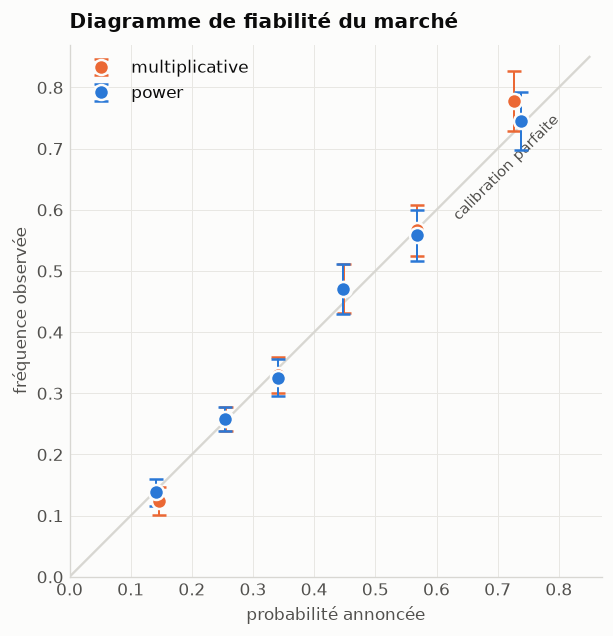

In [6]:
BINS = {
    m: calibration_bins(market_baseline(test, book="avg", method=m), outcomes)
    for m in ("multiplicative", "power")
}

fig, ax = plt.subplots(figsize=(5.6, 5.4))
ax.plot([0, 0.85], [0, 0.85], color=RULE, linewidth=1.4, zorder=1)
ax.annotate(
    "calibration parfaite",
    (0.62, 0.62),
    xytext=(6, -14),
    textcoords="offset points",
    fontsize=9,
    color=INK_2,
    rotation=45,
    rotation_mode="anchor",
)

for (method, table), colour in zip(BINS.items(), (ORANGE, BLUE), strict=True):
    p = np.array(table["predit_moyen"].to_list())
    o = np.array(table["observe"].to_list())
    n = np.array(table["n"].to_list())
    ci = 1.96 * np.sqrt(o * (1 - o) / n)
    ax.errorbar(
        p,
        o,
        yerr=ci,
        fmt="o",
        markersize=9,
        color=colour,
        ecolor=colour,
        elinewidth=1.2,
        capsize=4,
        label=method,
        zorder=3,
        markeredgecolor=SURFACE,
        markeredgewidth=1.5,
    )

ax.set_xlabel("probabilité annoncée")
ax.set_ylabel("fréquence observée")
ax.set_xlim(0, 0.87)
ax.set_ylim(0, 0.87)
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
ax.legend(loc="upper left")
ax.set_title("Diagramme de fiabilité du marché", loc="left", fontweight="bold", pad=10)
savefig("08_fiabilite_marche")

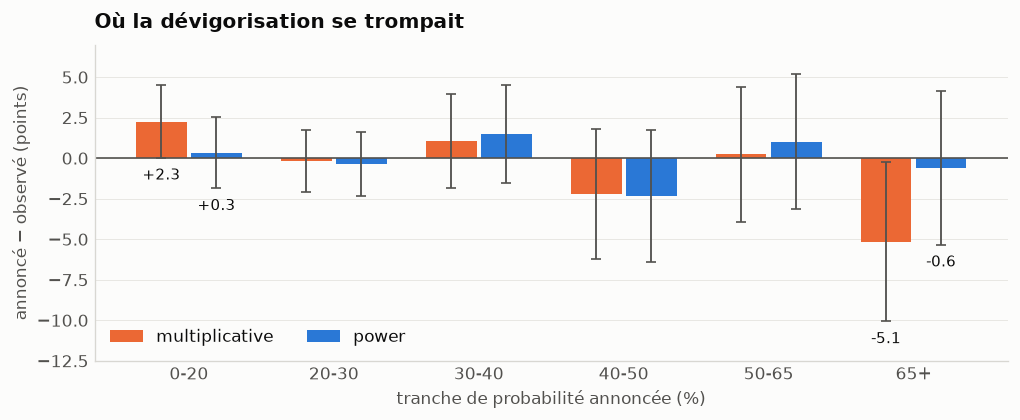

In [7]:
fig, ax = plt.subplots(figsize=(8.6, 3.6))
tranches = BINS["power"]["tranche"].to_list()
x = np.arange(len(tranches))
width = 0.38

# Only the two extreme bins carry the message; a number on every bar would be
# noise on top of noise.
LABELLED = {0, len(tranches) - 1}
for k, (method, colour) in enumerate((("multiplicative", ORANGE), ("power", BLUE))):
    table = BINS[method]
    gap = 100 * np.array(table["ecart"].to_list())
    o = np.array(table["observe"].to_list())
    n = np.array(table["n"].to_list())
    ci = 100 * 1.96 * np.sqrt(o * (1 - o) / n)
    offset = x + (k - 0.5) * width
    ax.bar(offset, gap, width=width - 0.03, color=colour, label=method)
    ax.errorbar(
        offset, gap, yerr=ci, fmt="none", ecolor=INK_2, elinewidth=1.1, capsize=3
    )
    for i in LABELLED:
        ax.annotate(
            f"{gap[i]:+.1f}",
            (offset[i], gap[i] - ci[i]),
            xytext=(0, -13),
            textcoords="offset points",
            ha="center",
            fontsize=9,
            color=INK,
        )

ax.axhline(0, color=INK_2, linewidth=1.0)
ax.set_xticks(x, tranches)
ax.set_xlabel("tranche de probabilité annoncée (%)")
ax.set_ylabel("annoncé − observé (points)")
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.set_ylim(-12.5, 7.0)
ax.legend(ncols=2, loc="lower left")
ax.set_title("Où la dévigorisation se trompait", loc="left", fontweight="bold", pad=10)
savefig("09_ecart_devig")

Le motif orange est systématique et il n'est pas dû au marché : la méthode
multiplicative **surestime les outsiders de 2.25 points** et **sous-estime les
favoris de 5.15 points**. La preuve qu'il s'agit de la méthode et non du
marché est quantitative : cette distorsion est proportionnelle à la marge du
bookmaker (rapport 1.81 entre la moyenne de marché et Pinnacle, pour un rapport
de marges de 1.77).

La méthode de puissance, `p_i = π_i^k`, retire proportionnellement plus de marge
aux petites probabilités — exactement là où le bookmaker la place. Le motif
disparaît.

Les barres d'erreur à 95 % sont là pour une raison : elles montrent que ce qui
reste après correction est du bruit d'échantillonnage, et qu'il ne faut rien en
conclure.

## 4. Les features : sept mesures, deux dimensions

*Régime : **saisons d'entraînement uniquement**. À partir d'ici on regarde le
signal, donc le test est hors limite.*

In [8]:
CUTOFF = TRAIN["date"].max()
FEATURES = build_features(MATCHES, CUTOFF).drop_nulls(list(FEATURE_COLUMNS))
print(
    f"{FEATURES.height} matchs d'entrainement avec les {len(FEATURE_COLUMNS)} features"
)
FEATURES.select(FEATURE_COLUMNS).describe().filter(
    pl.col("statistic").is_in(["null_count", "mean", "std", "min", "50%", "max"])
)

6836 matchs d'entrainement avec les 8 features


statistic,elo_diff,form_points_diff_5,goals_scored_diff_5,goals_conceded_diff_5,shots_target_diff_5,np_xg_created_diff_5,np_xg_conceded_diff_5,rest_days_diff
str,f64,f64,f64,f64,f64,f64,f64,f64
"""null_count""",0.0,0.0,0.0,0.0,0.0,0.0,0.0,0.0
"""mean""",65.736663,-0.032387,-0.029666,0.024781,-0.083382,-0.028734,0.026416,0.007314
"""std""",98.08112,0.961606,0.923425,0.842291,1.875255,0.663552,0.596624,1.682808
"""min""",-280.769333,-3.0,-3.8,-3.0,-7.8,-3.210403,-2.276188,-11.0
"""50%""",65.23643,0.0,0.0,0.0,0.0,-0.027419,0.022102,0.0
"""max""",399.215971,3.0,3.6,3.4,7.0,2.535454,2.7550042,12.0


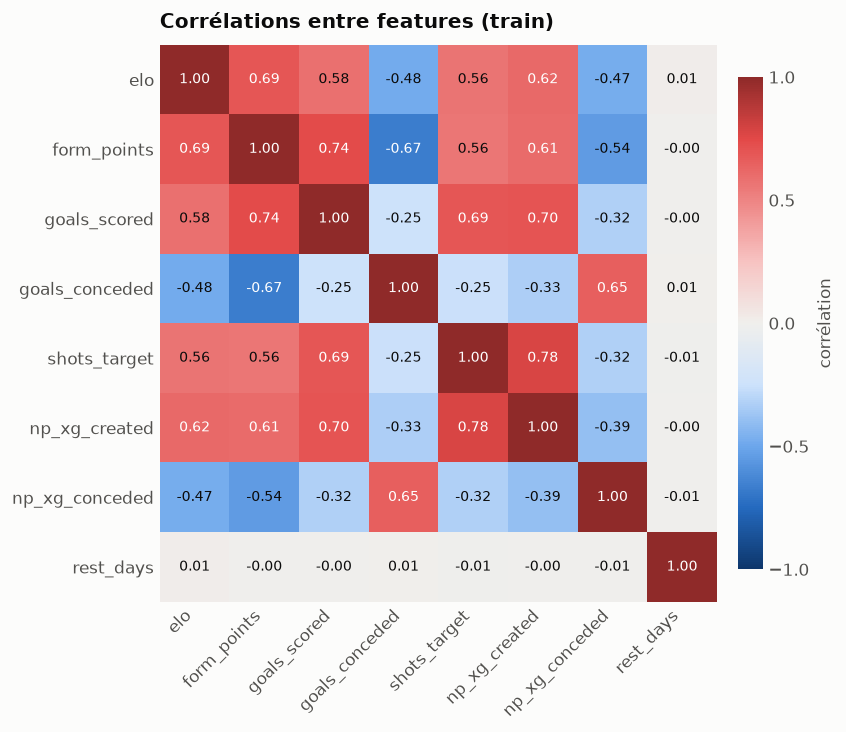

In [9]:
SHORT = [c.replace("_diff", "").replace("_5", "") for c in FEATURE_COLUMNS]
corr = np.corrcoef(FEATURES.select(FEATURE_COLUMNS).to_numpy(), rowvar=False)

fig, ax = plt.subplots(figsize=(7.4, 6.2))
image = ax.imshow(corr, cmap=CMAP_DIVERGING, vmin=-1, vmax=1)
ax.set_xticks(range(len(SHORT)), SHORT, rotation=45, ha="right")
ax.set_yticks(range(len(SHORT)), SHORT)
for i in range(len(SHORT)):
    for j in range(len(SHORT)):
        value = corr[i, j]
        ax.text(
            j,
            i,
            f"{value:.2f}",
            ha="center",
            va="center",
            fontsize=8.5,
            color="#ffffff" if abs(value) > 0.6 else INK,
        )
for s in ax.spines.values():
    s.set_visible(False)
bar = fig.colorbar(image, ax=ax, fraction=0.035, pad=0.03, ticks=[-1, -0.5, 0, 0.5, 1])
bar.set_label("corrélation", color=INK_2)
bar.outline.set_visible(False)
bar.ax.tick_params(length=0, colors=INK_2)
ax.set_title(
    "Corrélations entre features (train)", loc="left", fontweight="bold", pad=10
)
savefig("10_correlations_features")

Bleu foncé et rouge foncé signifient tous deux « redondant » : le signe ne dit
que le sens, l'intensité dit le recouvrement. Le gris central est la seule
couleur qui veut dire « indépendant ».

Lecture : les sept features de force forment un bloc coloré. `np_xg_created`
corrèle à **0.78** avec `shots_target` et **0.70** avec `goals_scored`. Elles
mesurent toutes la même chose latente — la force d'une équipe. Seule
`rest_days` est grise partout, à ±0.01.

**Tu n'as donc pas huit features, tu en as deux : la force et le repos.**
Conséquence directe pour la suite : ajouter une nouvelle variante de forme ne
servira à rien.

## 5. Mais alors, le xG sert-il à quelque chose ?

Oui — pas comme dimension nouvelle, comme **meilleure mesure de la même
dimension**. C'est exactement la thèse du xG : les buts sont une réalisation
très bruitée de la force d'une équipe, le xG mesure la même chose avec moins de
variance.

Le test : quelle fenêtre glissante prédit le mieux la marge de buts du match
**suivant** ?

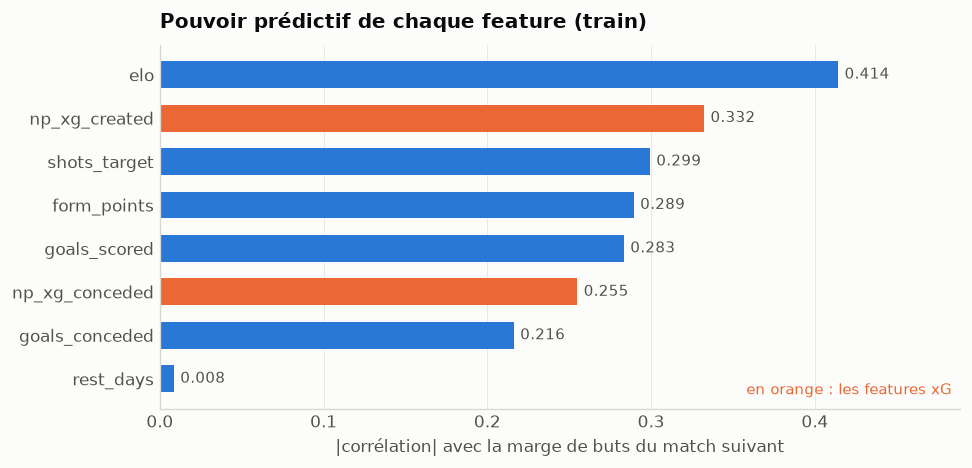

In [10]:
enriched = FEATURES.join(
    MATCHES.select("date", "home_team", "away_team", "home_goals", "away_goals"),
    on=["date", "home_team", "away_team"],
    how="inner",
)
margin = (enriched["home_goals"] - enriched["away_goals"]).to_numpy()
power = {
    c: abs(float(np.corrcoef(enriched[c].to_numpy(), margin)[0, 1]))
    for c in FEATURE_COLUMNS
}
ranked = sorted(power.items(), key=lambda kv: kv[1])

fig, ax = plt.subplots(figsize=(8.2, 4.0))
labels = [k.replace("_diff_5", "").replace("_diff", "") for k, _ in ranked]
values = [v for _, v in ranked]
colours = [BLUE if not k.startswith("np_xg") else ORANGE for k, _ in ranked]
bars = ax.barh(labels, values, height=0.62, color=colours)
ax.bar_label(bars, fmt="%.3f", padding=4, fontsize=9, color=INK_2)
ax.set_xlim(0, max(values) * 1.18)
ax.set_xlabel("|corrélation| avec la marge de buts du match suivant")
ax.xaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title(
    "Pouvoir prédictif de chaque feature (train)", loc="left", fontweight="bold", pad=10
)
ax.text(
    0.99,
    0.04,
    "en orange : les features xG",
    transform=ax.transAxes,
    ha="right",
    fontsize=9,
    color=ORANGE,
)
savefig("11_pouvoir_predictif")

`np_xg_created` bat `goals_scored` de 0.283 à 0.332, soit **17 % de pouvoir
prédictif en plus** pour mesurer la même chose. Understat valait donc le
détour, et le mapping des 35 noms d'équipes avec.

`elo_diff` domine tout le reste, ce qui est rassurant : c'est la seule feature
qui accumule toute l'histoire d'une équipe au lieu de ses cinq derniers matchs.

Et `rest_days` est à 0.01. Deux lectures possibles, qu'on ne peut pas encore
trancher : soit c'est du bruit pur, soit c'est une information que le marché
ignore et donc précisément là où un avantage se cacherait. La Phase 4 le dira.

## 6. Ce que l'Elo raconte

Les notes Elo des cinq équipes les mieux classées à la fin de la période. Rien
ici ne sert à prédire — c'est un contrôle de plausibilité, et le meilleur moyen
de vérifier d'un coup d'œil que le calcul fait ce qu'on croit.

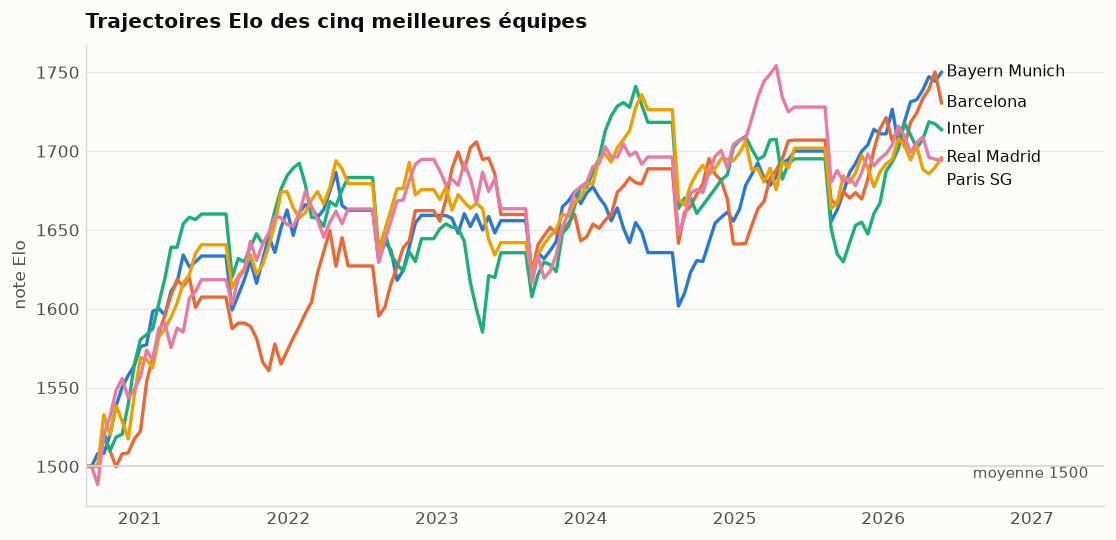

In [11]:
elo = EloRatings().fit(MATCHES)
last_day = MATCHES["date"].max()
teams = sorted(
    set(MATCHES["home_team"].unique()),
    key=lambda t: elo.get_rating(t, last_day),
    reverse=True,
)[:5]

timeline = [
    MATCHES["date"].min() + (last_day - MATCHES["date"].min()) * i / 140
    for i in range(141)
]

curves = {team: [elo.get_rating(team, day) for day in timeline] for team in teams}

fig, ax = plt.subplots(figsize=(9.4, 4.6))
for series, colour in zip(curves.values(), SERIES, strict=True):
    ax.plot(timeline, series, color=colour, linewidth=2)

# Direct labels at the line ends, pushed apart so none sits on another.
span = max(max(v) for v in curves.values()) - min(min(v) for v in curves.values())
gap = span * 0.055
placed: list[float] = []
for team, series in sorted(curves.items(), key=lambda kv: kv[1][-1], reverse=True):
    y = series[-1]
    if placed and placed[-1] - y < gap:
        y = placed[-1] - gap
    placed.append(y)
    ax.annotate(f" {team}", (timeline[-1], y), fontsize=9.5, color=INK, va="center")

ax.axhline(1500, color=RULE, linewidth=1.0)
ax.text(
    0.985,
    1500,
    "moyenne 1500",
    transform=ax.get_yaxis_transform(),
    ha="right",
    va="top",
    fontsize=9,
    color=INK_2,
)
ax.set_ylabel("note Elo")
ax.set_xlim(timeline[0], timeline[-1] + (timeline[-1] - timeline[0]) * 0.19)
ax.yaxis.grid(True)
ax.set_axisbelow(True)
ax.set_title(
    "Trajectoires Elo des cinq meilleures équipes",
    loc="left",
    fontweight="bold",
    pad=10,
)
savefig("12_trajectoires_elo")

Les décrochages nets entre saisons sont la régression de 25 % vers la moyenne,
appliquée pendant l'intersaison pour absorber les promus et les relégués. Les
courbes restent dans une bande d'environ 1300 à 1750, ce qui est l'ordre de
grandeur attendu au football : contrairement aux échecs, un match de foot est
si aléatoire que même les meilleures équipes ne s'échappent jamais très loin.

## 7. xG contre buts, sur une saison

Dernier diagramme, celui qui rend le xG intuitif. Chaque point est une
équipe-saison : buts réellement marqués contre xG accumulé.

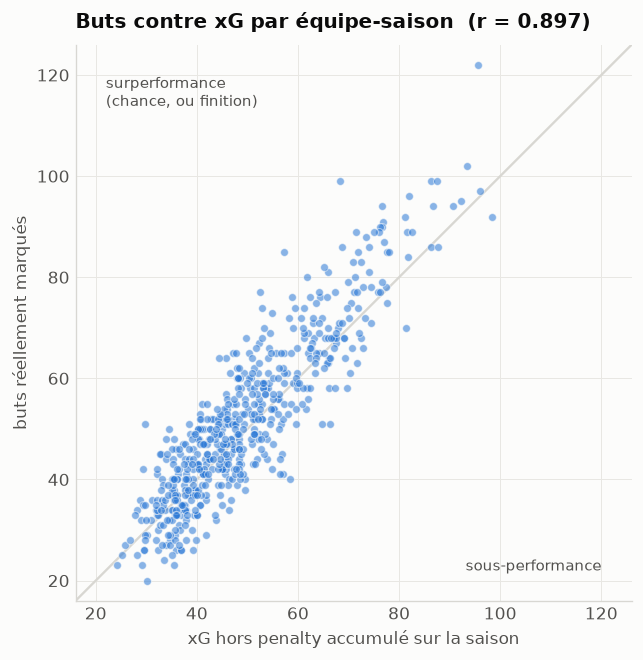

In [12]:
per_team = (
    pl.concat(
        [
            MATCHES.select(
                "season",
                pl.col("home_team").alias("team"),
                pl.col("home_goals").alias("goals"),
                pl.col("home_np_xg").alias("np_xg"),
            ),
            MATCHES.select(
                "season",
                pl.col("away_team").alias("team"),
                pl.col("away_goals").alias("goals"),
                pl.col("away_np_xg").alias("np_xg"),
            ),
        ]
    )
    .group_by("season", "team")
    .agg(
        pl.col("goals").sum().alias("buts"),
        pl.col("np_xg").sum().round(1).alias("np_xg"),
    )
)

fig, ax = plt.subplots(figsize=(5.8, 5.6))
low = min(per_team["np_xg"].min(), per_team["buts"].min()) - 4
high = max(per_team["np_xg"].max(), per_team["buts"].max()) + 4
ax.plot([low, high], [low, high], color=RULE, linewidth=1.4, zorder=1)
ax.scatter(
    per_team["np_xg"],
    per_team["buts"],
    s=22,
    color=BLUE,
    alpha=0.55,
    edgecolor=SURFACE,
    linewidth=0.6,
    zorder=3,
)
ax.annotate(
    "surperformance\n(chance, ou finition)",
    (low + 6, high - 6),
    fontsize=9,
    color=INK_2,
    va="top",
)
ax.annotate(
    "sous-performance", (high - 6, low + 6), fontsize=9, color=INK_2, ha="right"
)
ax.set_xlabel("xG hors penalty accumulé sur la saison")
ax.set_ylabel("buts réellement marqués")
ax.set_xlim(low, high)
ax.set_ylim(low, high)
ax.set_aspect("equal")
ax.grid(True)
ax.set_axisbelow(True)
r = float(np.corrcoef(per_team["np_xg"], per_team["buts"])[0, 1])
ax.set_title(
    f"Buts contre xG par équipe-saison  (r = {r:.3f})",
    loc="left",
    fontweight="bold",
    pad=10,
)
savefig("13_buts_vs_xg")

Les points serrés autour de la diagonale disent que le xG mesure bien la même
chose que les buts. La dispersion qui reste, c'est ce qui sépare la performance
du processus : une équipe très au-dessus de la diagonale a marqué plus que ce
que ses occasions valaient, et cet écart ne se reproduit généralement pas la
saison suivante. C'est précisément pour cette raison qu'une fenêtre glissante
en xG prédit mieux qu'une fenêtre glissante en buts.

---

## Ce qu'il faut retenir

1. **Le terrain de jeu fait 0.094.** Entre 1.0721 (`uniform`) et 0.9769
   (`market`). Un modèle à 1.03 aura capturé 45 % de l'écart disponible.
2. **Le plancher est à 0.98.** Sous ce niveau, cherche la fuite.
3. **L'accuracy ne mesure pas ce qu'on veut.** Même accuracy, log-loss ×18.
4. **Ne jamais optimiser l'ECE seul.** `uniform` est mieux calibrée que le
   marché tout en étant inutile : il faut de la calibration *et* du pouvoir
   discriminant.
5. **Huit features, deux dimensions.** La force et le repos. Ajouter des
   variantes de forme ne servira à rien.
6. **Le xG vaut 17 % de pouvoir prédictif en plus que les buts**, pour mesurer
   la même chose.
7. **`rest_days` est à décider en Phase 4** : bruit pur, ou information que le
   marché ignore ?